# Checking students work for AI-generated solutions.

Final Score = w1 * StyleScore 
            + w2 * ComplexityScore
            + w3 * LLMScore
            + w4 * SimilarityScore
            + w5 * SemanticScore

# Style analysis 

In [21]:
import ast
import re

def extract_style_features(code: str, language: str = ".py"):

    if language == ".py":
        return _extract_python_features(code)
    
    elif language in [".cpp", ".cs", ".pas", ".c"]:
        return _extract_cpp_features(code)
    
    else:
        raise ValueError(f"Unsupported language: {language}")
    
def _extract_python_features(code: str):
    try:
        tree = ast.parse(code)
    except:
        return _fallback_features(code)

    var_names = []

    for node in ast.walk(tree):
        if isinstance(node, ast.Name):
            var_names.append(node.id)

    avg_len = sum(len(v) for v in var_names) / (len(var_names) + 1)

    comment_count = len(re.findall(r'#.*', code))
    lines = len(code.split('\n'))
    comment_density = comment_count / (lines + 1)

    return {
        "avg_var_length": avg_len,
        "comment_density": comment_density,
        "num_variables": len(var_names)
    }

def _fallback_features(code: str):
    words = re.findall(r'\b[a-zA-Z_]{2,}\b', code)

    avg_len = sum(len(w) for w in words) / (len(words) + 1)

    comment_count = len(re.findall(r'#|//', code))
    lines = len(code.split('\n'))

    return {
        "avg_var_length": avg_len,
        "comment_density": comment_count / (lines + 1),
        "num_variables": len(words)
    }

def _extract_cpp_features(code: str):
    # Remove strings (to avoid false positives)
    code_clean = re.sub(r'"(\\.|[^"])*"', '', code)

    # Variable detection (simple heuristic)
    var_pattern = r'\b(int|float|double|char|bool|long|auto|string)\s+([a-zA-Z_][a-zA-Z0-9_]*)'
    matches = re.findall(var_pattern, code_clean)

    var_names = [m[1] for m in matches]

    avg_len = sum(len(v) for v in var_names) / (len(var_names) + 1)

    # Comments: // and /* */
    single_comments = re.findall(r'//.*', code)
    multi_comments = re.findall(r'/\*[\s\S]*?\*/', code)

    comment_count = len(single_comments) + len(multi_comments)

    lines = len(code.split('\n'))
    comment_density = comment_count / (lines + 1)

    return {
        "avg_var_length": avg_len,
        "comment_density": comment_density,
        "num_variables": len(var_names)
    }

## All together

In [22]:
def analyze_code_style(code: str, language: str = ".py"):
    features = extract_style_features(code, language)
    return features

## Go over all files and check

Error reading 2026-05-02 07-20-24.877700, tun_20_06, task_2026_14, Scored (6.0 - 100.0), task_2026_14.py: 'charmap' codec can't decode byte 0x8f in position 418: character maps to <undefined>
Error reading 2026-05-02 07-24-03.965795, tun_20_06, task_2026_14, Scored (6.0 - 100.0), task_2026_14.py: 'charmap' codec can't decode byte 0x8f in position 547: character maps to <undefined>
Error reading 2026-05-02 07-29-26.418949, tun_20_06, task_2026_12, Scored (52.0 - 100.0), task_2026_12.py: 'charmap' codec can't decode byte 0x81 in position 105: character maps to <undefined>
Error reading 2026-05-02 07-30-52.212384, tun_20_06, task_2026_12, Scored (52.0 - 100.0), task_2026_12.py: 'charmap' codec can't decode byte 0x81 in position 105: character maps to <undefined>
Error reading 2026-05-02 07-31-15.584430, tun_20_06, task_2026_14, Scored (6.0 - 100.0), task_2026_14.py: 'charmap' codec can't decode byte 0x8f in position 547: character maps to <undefined>
Error reading 2026-05-02 07-31-19.5811

<unknown>:3: SyntaxWarning: invalid decimal literal
C:\Users\vmelnyk2\AppData\Local\Temp\ipykernel_35168\102168946.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[feature_name])


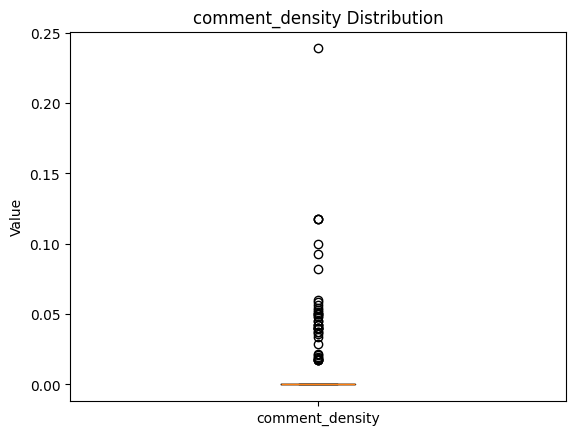

C:\Users\vmelnyk2\AppData\Local\Temp\ipykernel_35168\102168946.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[feature_name])


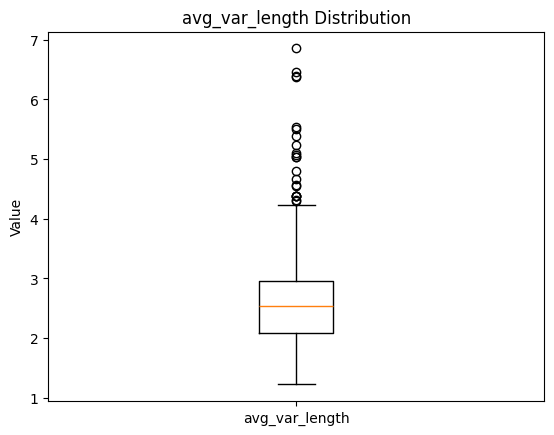

C:\Users\vmelnyk2\AppData\Local\Temp\ipykernel_35168\102168946.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[feature_name])


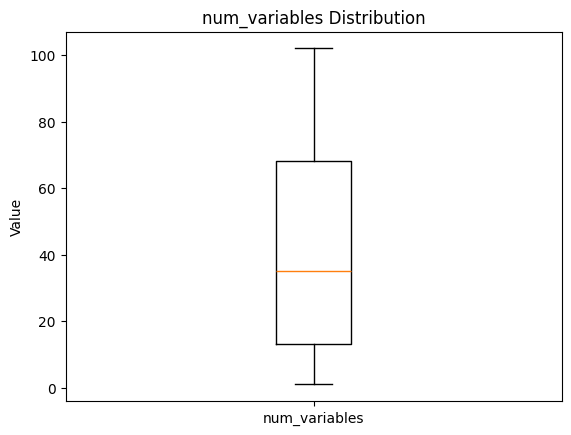

Outliers in comment_density:
2026-05-02 07-14-11.715144, sl16, task_2026_12, Scored (52.0 - 100.0), task_2026_12.cpp (nickname: sl16) - comment_density: 0.06
2026-05-02 07-17-06.141948, NotNiure, task_2026_11, Scored (0.0 - 100.0), task_2026_11.py (nickname: NotNiure) - comment_density: 0.11764705882352941
2026-05-02 07-18-18.899900, NotNiure, task_2026_15, Scored (60.0 - 100.0), task_2026_15.py (nickname: NotNiure) - comment_density: 0.11764705882352941
2026-05-02 07-23-38.826129, NotNiure, task_2026_15, Scored (100.0 - 100.0), task_2026_15.py (nickname: NotNiure) - comment_density: 0.1
2026-05-02 07-37-03.089403, sl16, task_2026_15, Scored (100.0 - 100.0), task_2026_15.cpp (nickname: sl16) - comment_density: 0.04477611940298507
2026-05-02 07-40-27.150259, NotNiure, task_2026_13, Scored (60.0 - 100.0), task_2026_13.py (nickname: NotNiure) - comment_density: 0.05
2026-05-02 07-42-04.405770, NotNiure, task_2026_13, Scored (60.0 - 100.0), task_2026_13.py (nickname: NotNiure) - comment_de

In [25]:
import os

folder_path = os.path.join(os.getcwd(), "submissions")

student_nicknames = set()
filenames = os.listdir(folder_path)

for filename in filenames:
    nickname = filename.split(",")[1].strip()
    student_nicknames.add(nickname)

# print("Unique student nicknames:")
# for nickname in student_nicknames:
#     print(nickname)

feture_list = []

for file_name in filenames:
    nickname = file_name.split(",")[1].strip()
    
    try:
        file_content = open(os.path.join(folder_path, file_name)).read()
    except Exception as e:
        print(f"Error reading {file_name}: {e}")
        continue

    extension = os.path.splitext(file_name)[1]
    features = analyze_code_style(file_content, language=extension)

    features["nickname"] = nickname
    features["file_name"] = file_name
    feture_list.append(features)

import numpy as np
import matplotlib.pyplot as plt

def display_box_plot(feature_name):
    data = [f[feature_name] for f in feture_list]
    plt.boxplot(data, labels=[feature_name])
    plt.title(f'{feature_name} Distribution')
    plt.ylabel('Value')
    plt.show()

display_box_plot("comment_density")
display_box_plot("avg_var_length")
display_box_plot("num_variables")

def detect_outliers(feature_name):
    data = np.array([f[feature_name] for f in feture_list])
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = [f for f in feture_list if f[feature_name] < lower_bound or f[feature_name] > upper_bound]
    return outliers

print("Outliers in comment_density:")
outliers = detect_outliers("comment_density")
for o in outliers:
    print(f"{o['file_name']} (nickname: {o['nickname']}) - comment_density: {o['comment_density']}")

print("\nOutliers in avg_var_length:")
outliers = detect_outliers("avg_var_length")
for o in outliers:
    print(f"{o['file_name']} (nickname: {o['nickname']}) - avg_var_length: {o['avg_var_length']}")

print("\nOutliers in num_variables:")
outliers = detect_outliers("num_variables")
for o in outliers:
    print(f"{o['file_name']} (nickname: {o['nickname']}) - num_variables: {o['num_variables']}")
# print(feture_list)